eps를 사람이 정해야 함

→ 너무 어려움

→ 데이터마다 다름

k-distance graph = eps 자동 탐색 방법

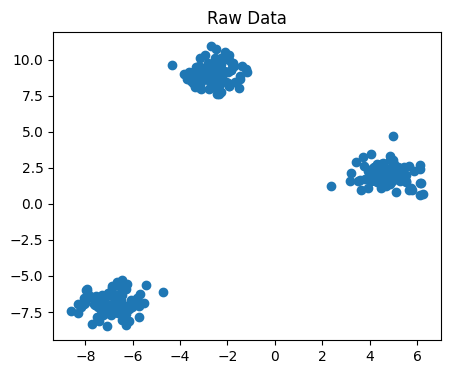

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52286 (\N{HANGUL SYLLABLE CAJ}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


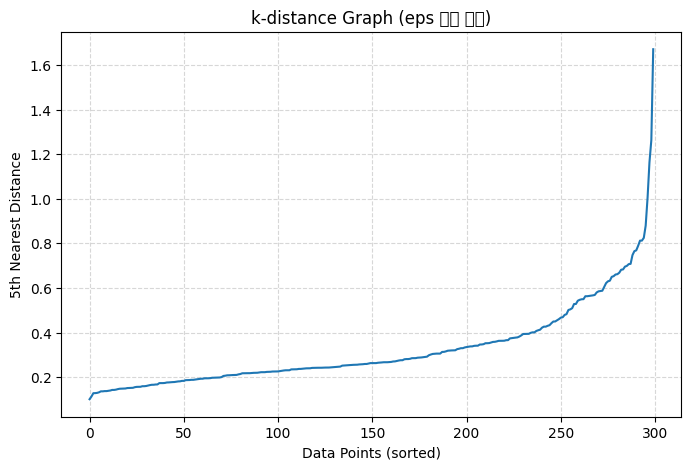

🔥 추천 eps (대략): 0.58


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors

# =========================
# 1️⃣ 데이터 생성 (DBSCAN용)
# =========================
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.7,
    random_state=42
)

plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1])
plt.title("Raw Data")
plt.show()


# =========================
# 2️⃣ k 설정 (핵심)
# =========================
k = 5   # 보통 min_samples와 동일하게 설정

# =========================
# 3️⃣ k-NN 거리 계산
# =========================
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X)
distances, indices = nbrs.kneighbors(X)


# =========================
# 4️⃣ k번째 거리 추출
# =========================
k_distances = distances[:, k-1]

# 정렬 (핵심)
k_distances = np.sort(k_distances)


# =========================
# 5️⃣ k-distance graph
# =========================
plt.figure(figsize=(8,5))

plt.plot(k_distances)

plt.title("k-distance Graph (eps 후보 찾기)")
plt.xlabel("Data Points (sorted)")
plt.ylabel(f"{k}th Nearest Distance")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


# =========================
# 6️⃣ eps 선택 힌트 출력
# =========================
eps_estimate = np.percentile(k_distances, 90) # 90%가 이 값 이하

# 예)  eps = 1.2 eps_estimate = np.percentile(k_distances, 90)
# → 전체 데이터의 90%
# 1.2 거리 안에 이웃이 존재

print("🔥 추천 eps (대략):", round(eps_estimate, 3)) #상위 10% 정도 큰 거리(이상치 후보)는 제외 , 나머지 90% 데이터를 포함하도록 선택

# eps가 너무 작으면:
# 거의 전부 Noise
